In [25]:
from result_analysis.utilities.helpers import get_result_dir
from my_helpers.general_helpers import load_json

import itertools
import configs

# 1to1

## binary 1to1

In [26]:
import os

base_dir = "../test_result"
behavior = "3-stirring-fast"
data_name = "dataset_discretized.bin"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [behavior],
    "target_beh_list": [behavior],
    "test_object_list": [],
    "shared_object_list": [],
}

cross_tool_pair = list(itertools.permutations(configs.ALL_TOOL_LIST, 2))
pair_results_bin = {}
for pair in cross_tool_pair:
    context_dict['source_tool_list'] = [pair[0]]
    context_dict['target_tool_list'] = [pair[1]]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type="shared",
                                     modality="audio", data_name=data_name)
    result = load_json(os.path.join(test_result_dir, "results1.json")) 
    pair_results_bin[f"{pair[0]}2{pair[1]}"] = result
    

In [27]:
conf_matrix_bin = make_confusion_matrix(pair_results_bin)
conf_matrix_bin

,metal-scissor,metal-whisk,plastic-knife,plastic-spoon,wooden-chopstick,wooden-fork
metal-scissor,NaN,0.750,0.642,0.592,0.708,0.642
metal-whisk,0.714,NaN,0.722,0.692,0.726,0.808
plastic-knife,0.706,0.708,NaN,0.728,0.716,0.742
plastic-spoon,0.628,0.698,0.714,NaN,0.640,0.718
wooden-chopstick,0.698,0.732,0.732,0.606,NaN,0.672
wooden-fork,0.668,0.802,0.706,0.730,0.726,NaN


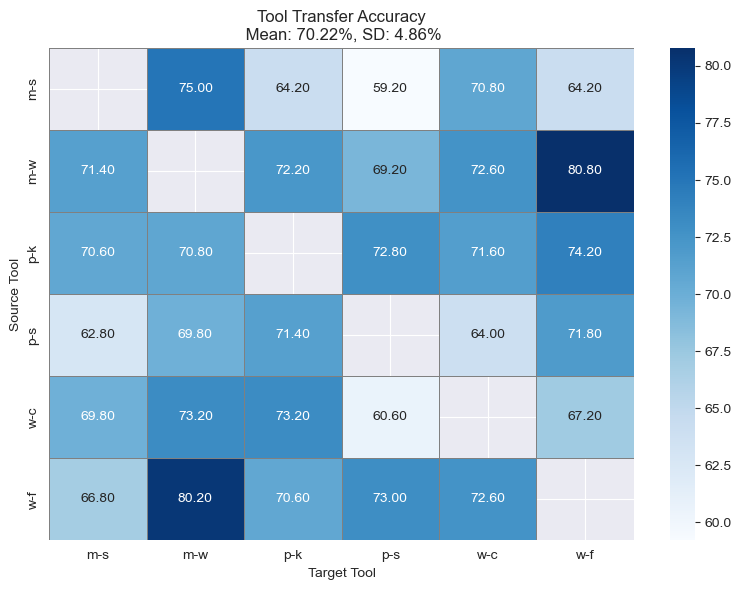

In [44]:
plot_confusion_matrix(conf_matrix=conf_matrix_bin*100)

## audio clap 1to 1

In [57]:
import os

base_dir = "../test_result"
behavior = "3-stirring-fast"
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [behavior],
    "target_beh_list": [behavior],
    "test_object_list": [],
    "shared_object_list": [],
}

cross_tool_pair = list(itertools.permutations(configs.ALL_TOOL_LIST, 2))
pair_results_clap = {}
for pair in cross_tool_pair:
    context_dict['source_tool_list'] = [pair[0]]
    context_dict['target_tool_list'] = [pair[1]]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type="shared",
                                     modality="audio", data_name=data_name)
    
    try:
        result = load_json(os.path.join(test_result_dir, "results1.json")) 
        pair_results_clap[f"{pair[0]}2{pair[1]}"] = result
        # print(f"pair_exist: {pair[0]}2{pair[1]}")
    except FileNotFoundError:
        print(f"no result: {test_result_dir}")
        continue  

In [64]:
conf_matrix_clap_to1 = make_confusion_matrix(pair_results_clap)
conf_matrix_clap_to1

,metal-scissor,metal-whisk,plastic-knife,plastic-spoon,wooden-chopstick,wooden-fork
metal-scissor,NaN,0.826,0.820,0.776,0.830,0.782
metal-whisk,0.796,NaN,0.846,0.816,0.844,0.840
plastic-knife,0.772,0.858,NaN,0.868,0.846,0.872
plastic-spoon,0.736,0.810,0.852,NaN,0.830,0.812
wooden-chopstick,0.806,0.884,0.856,0.832,NaN,0.782
wooden-fork,0.774,0.818,0.860,0.846,0.800,NaN


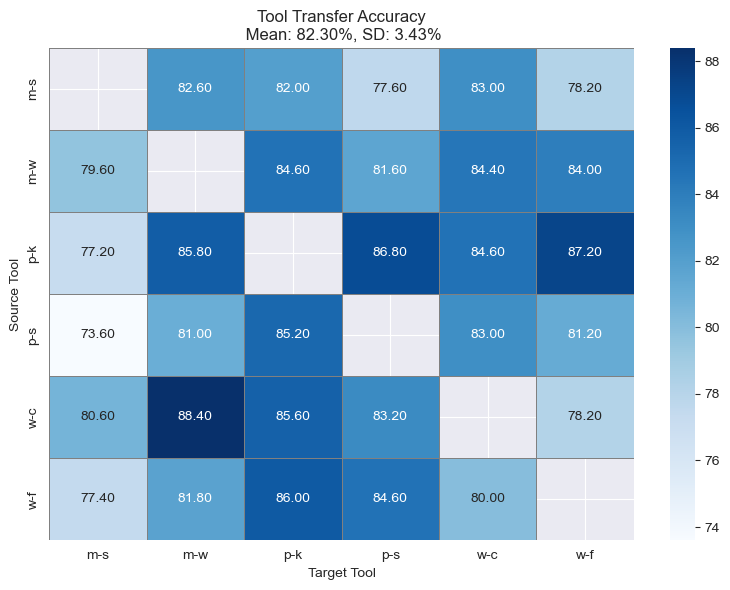

In [65]:
plot_confusion_matrix(conf_matrix=conf_matrix_clap_to1*100)

In [66]:
np.mean(conf_matrix_clap_to1)

0.8230000000000001

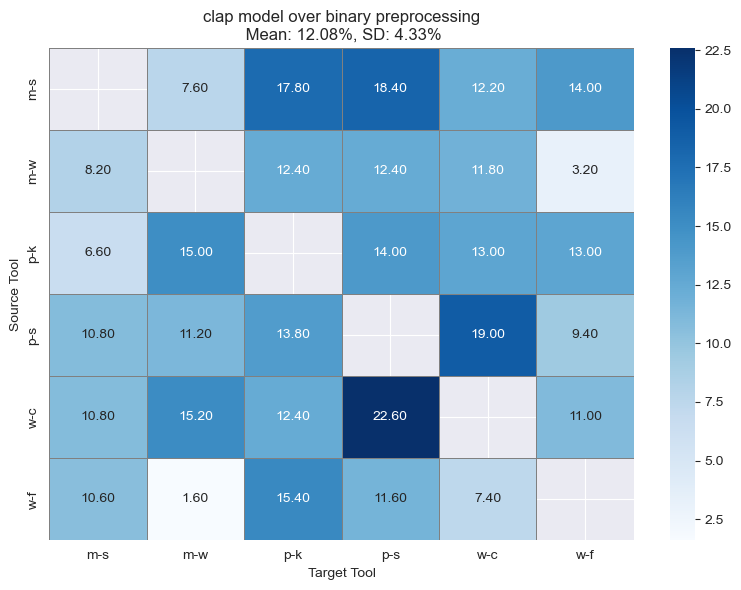

In [67]:
plot_confusion_matrix(conf_matrix=(conf_matrix_clap_to1-conf_matrix_bin)*100, 
                      title="clap model over binary preprocessing")

In [69]:
mean_per_target_tool(conf_matrix=conf_matrix_clap_to1)

metal-scissor       0.7768
metal-whisk         0.8392
plastic-knife       0.8468
plastic-spoon       0.8276
wooden-chopstick    0.8300
wooden-fork         0.8176
dtype: float64

# 5to1

## binary 5to1

In [106]:
import os

base_dir = "../test_result"
behavior = "3-stirring-fast"
data_name = "dataset_discretized.bin"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_bin_5to1 = {}
for tgt_t in configs.ALL_TOOL_LIST:
    src_t_list = sorted(t for t in configs.ALL_TOOL_LIST if t != tgt_t)
    context_dict['source_tool_list'] = src_t_list
    context_dict['target_tool_list'] = [tgt_t]
    
    context_dict['source_beh_list'] = [behavior]
    context_dict['target_beh_list'] = [behavior]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type="shared",
                                     modality="audio", data_name=data_name)
    
    try:
        result = load_json(os.path.join(test_result_dir, "results1.json")) 
        pair_results_bin_5to1[f"source_{tgt_t}&{behavior}"] = result
        # print(f"pair_exist: source_{tgt_t}&{beh}")
    except FileNotFoundError:
        print(f"no result: {test_result_dir}")
        continue  

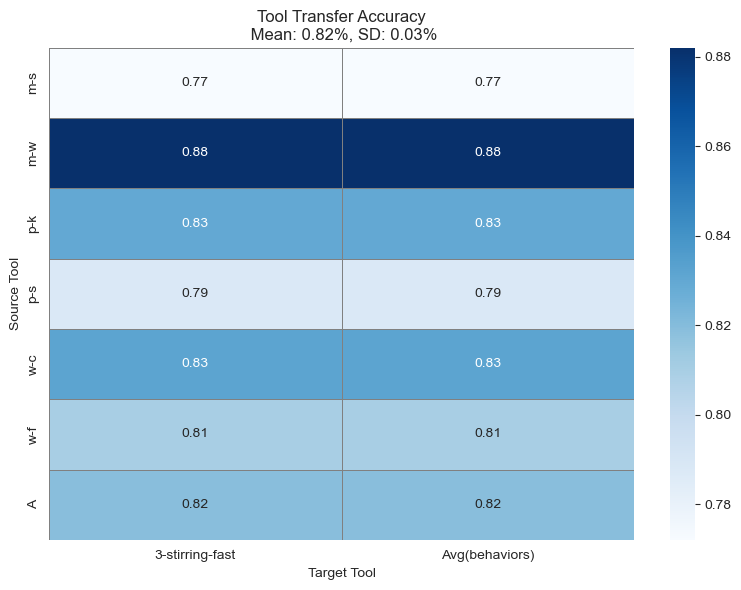

In [111]:
bin_5to1 = make_target_behavior_matrix(pair_results_bin_5to1)
plot_confusion_matrix(bin_5to1)

## clap 5to1

In [72]:
import os

base_dir = "../test_result"
behavior = "3-stirring-fast"
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_clap = {}
for tgt_t in configs.ALL_TOOL_LIST:
    src_t_list = sorted(t for t in configs.ALL_TOOL_LIST if t != tgt_t)
    context_dict['source_tool_list'] = src_t_list
    context_dict['target_tool_list'] = [tgt_t]
    for beh in configs.ALL_BEH_LIST:
        context_dict['source_beh_list'] = [beh]
        context_dict['target_beh_list'] = [beh]
        test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type="shared",
                                         modality="audio", data_name=data_name)
    
        try:
            result = load_json(os.path.join(test_result_dir, "results1.json")) 
            pair_results_clap[f"source_{tgt_t}&{beh}"] = result
            # print(f"pair_exist: source_{tgt_t}&{beh}")
        except FileNotFoundError:
            print(f"no result: {test_result_dir}")
            continue  

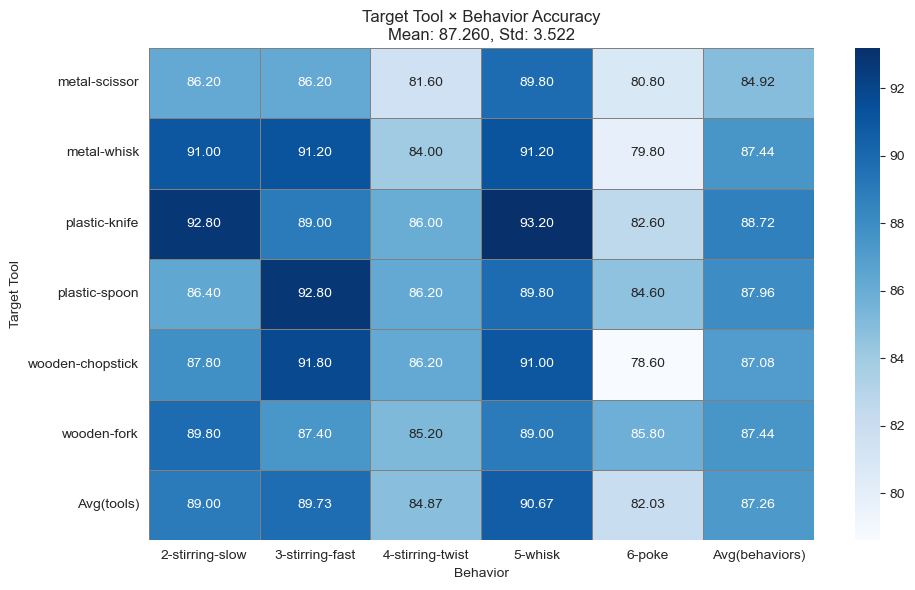

In [74]:
conf_matrix_clap = make_target_behavior_matrix(pair_results_clap)
plot_target_behavior_matrix(df_matrix=conf_matrix_clap*100)

In [81]:
conf_matrix_clap

behavior
2-stirring-slow     0.9100
3-stirring-fast     0.9120
4-stirring-twist    0.8400
5-whisk             0.9120
6-poke              0.7980
Avg(behaviors)      0.8744
Name: metal-whisk, dtype: float64

In [88]:
conf_matrix_clap[:1]

behavior,2-stirring-slow,3-stirring-fast,4-stirring-twist,5-whisk,6-poke,Avg(behaviors)
target_tool,,,,,,
metal-scissor,0.862,0.862,0.816,0.898,0.808,0.8492


In [89]:
0.862 - 0.7768

0.08519999999999994

### binary vs. clap

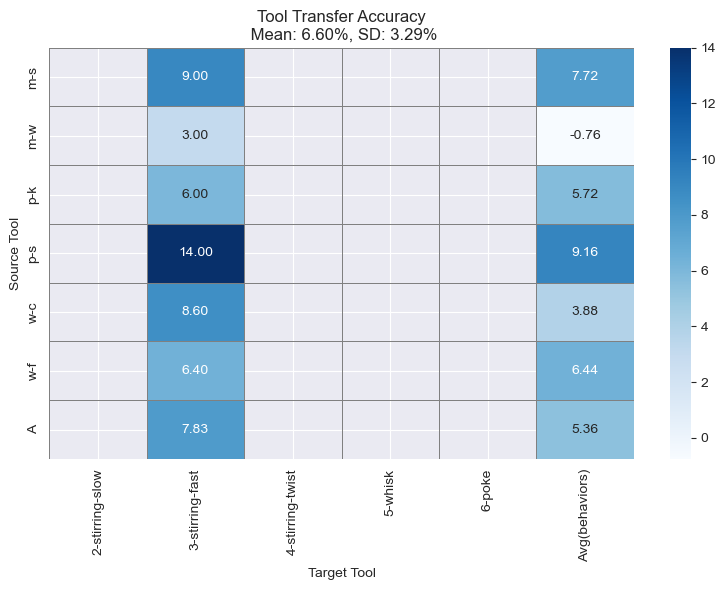

In [114]:
plot_confusion_matrix((conf_matrix_clap - bin_5to1)*100)

### 5to1 vs 1to1

In [91]:
compare_to1_vs_5to1(conf_matrix_clap_to1, conf_matrix_clap, behavior="3-stirring-fast")

{'1-to-1': {'mean': 0.823,
  'std': 0.024749303020489263,
  'per_target': metal-scissor       0.7768
  metal-whisk         0.8392
  plastic-knife       0.8468
  plastic-spoon       0.8276
  wooden-chopstick    0.8300
  wooden-fork         0.8176
  dtype: float64},
 '5-to-1': {'mean': 0.8973333333333332,
  'std': 0.02390722810272145,
  'per_target': target_tool
  metal-scissor       0.862000
  metal-whisk         0.912000
  plastic-knife       0.890000
  plastic-spoon       0.928000
  wooden-chopstick    0.918000
  wooden-fork         0.874000
  Avg(tools)          0.897333
  Name: 3-stirring-fast, dtype: float64}}

In [94]:
df_diff = diff_5to1_minus_1to1(conf_matrix_clap_to1*100, conf_matrix_clap*100, behavior="3-stirring-fast")
print(df_diff)

                  1-to-1  5-to-1  diff (5to1-1to1)
metal-scissor      77.68    86.2              8.52
metal-whisk        83.92    91.2              7.28
plastic-knife      84.68    89.0              4.32
plastic-spoon      82.76    92.8             10.04
wooden-chopstick   83.00    91.8              8.80
wooden-fork        81.76    87.4              5.64


# Cross behavior

In [96]:
import os

base_dir = "../test_result"
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_clap_cB = {}
for tgt_b in configs.ALL_BEH_LIST:
    src_b_list = sorted(b for b in configs.ALL_BEH_LIST if b != tgt_b)
    context_dict['source_beh_list'] = src_b_list
    context_dict['target_beh_list'] = [tgt_b]
    for tool in configs.ALL_TOOL_LIST:
        context_dict['source_tool_list'] = [tool]
        context_dict['target_tool_list'] = [tool]
        test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type="shared",
                                         modality="audio", data_name=data_name)
    
        try:
            result = load_json(os.path.join(test_result_dir, "results1.json")) 
            pair_results_clap_cB[f"source_{tgt_b}&{tool}"] = result
            # print(f"pair_exist: source_{tgt_t}&{beh}")
        except FileNotFoundError:
            print(f"no result: {test_result_dir}")
            continue  

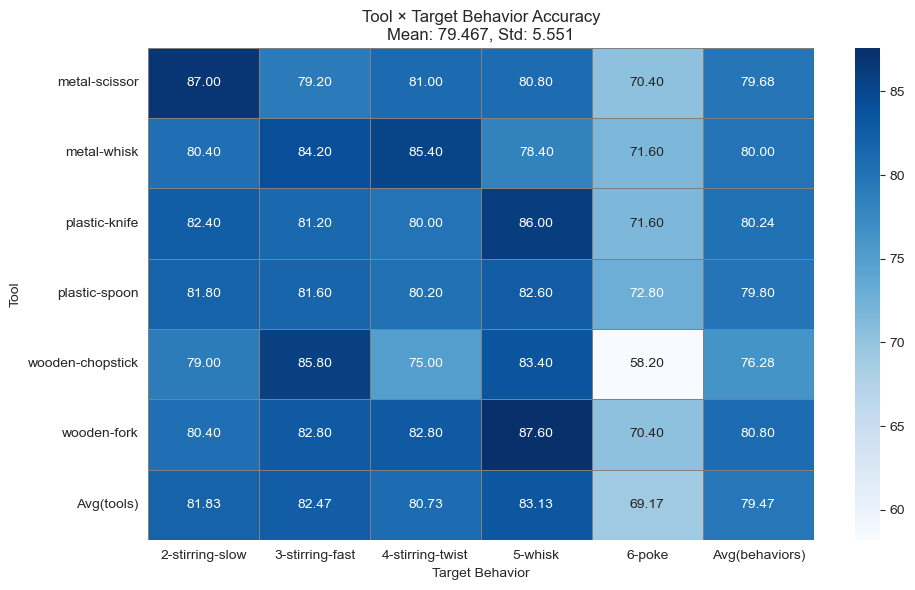

In [100]:
cm_cB_5to1 = make_tool_behavior_matrix(pair_results_clap_cB)
plot_tool_behavior_matrix(cm_cB_5to1*100)

# last cell